# Outline

This project aims to build a scoring model for evaluating forwards across Europe's top five leagues during the 2024–25 season. Rather than focusing only on goals and assists, the model attempts to evaluate different aspects of a forward's performance and combine them into a single overall score.

To reduce the influence of small sample sizes, only players whose primary position is forward and who have played more than 1,000 minutes are included. Most player statistics are converted into per-90-minute values, allowing players with different amounts of playing time to be compared more fairly. Each statistic is then converted into a percentile rank among all qualified forwards.

The model evaluates players in four main categories:

* **Goal Scoring:** non-penalty expected goals (npxG) and non-penalty goals above expected (np:G-xG)
* **Creativity:** progressive carries, progressive passes, expected assists, and key passes
* **Defense:** tackles won, interceptions, and blocks
* **Ball Control:** miscontrols and dispossessions, where fewer mistakes result in a higher score

Since winning a penalty directly creates a high-quality scoring opportunity, penalties won are also included as a small bonus.

The four category scores are combined into a total score, with Goal Scoring and Creativity receiving the greatest weights because the model is designed specifically for forwards. Finally, I apply a small league-strength adjustment to the total score. Based on my personal experience watching European football, I assign coefficients of 1.00 to the Premier League, 0.98 to La Liga, and 0.96 to Serie A, the Bundesliga, and Ligue 1. These coefficients are intentionally small because league strength should adjust the evaluation rather than dominate individual performance.


In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/archive/players_data_light-2024_2025.csv")
pd.set_option('display.max_columns', None)

In [168]:
list(df.head())

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Comp',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'G+A-PK',
 'xG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'FK',
 'PK_stats_shooting',
 'PKatt_stats_shooting',
 'xG_stats_shooting',
 'npxG_stats_shooting',
 'npxG/Sh',
 'G-xG',
 'np:G-xG',
 'Cmp',
 'Att',
 'Cmp%',
 'TotDist',
 'PrgDist',
 'Ast_stats_passing',
 'xAG_stats_passing',
 'xA',
 'A-xAG',
 'KP',
 '1/3',
 'PPA',
 'CrsPA',
 'PrgP_stats_passing',
 'Live',
 'Dead',
 'FK_stats_passing_types',
 'TB',
 'Sw',
 'Crs',
 'TI',
 'CK',
 'In',
 'Out',
 'Str',
 'Cmp_stats_passing_types',
 'Tkl',
 'TklW',
 'Def 3rd',
 'Mid 3rd',
 'Att 3rd',
 'Att_stats_defense',
 'Tkl%',
 'Lost',
 'Blocks_stats_defense',
 'Sh_stats_defense',
 'Pass',
 'Int',
 'Tkl+Int',
 'Clr',
 'Err',
 'SCA',
 'SCA90',
 'PassLive',
 'PassDead',
 'TO',


In [169]:
df[df['Pos']=='FW']['Min'].head(20)

4         3
13     2768
17        1
18     1183
22      134
23     1075
24     2652
26     1545
58       13
60     2495
72      639
75       62
88        2
89     1750
94      157
103    2509
106       1
119    2467
126    1188
129       6
Name: Min, dtype: int64

In [170]:
df['Pos'].unique()
# DF: defender; MF: midfielder; FW: forward; GK: goalkeeper

<StringArray>
['DF', 'DF,MF', 'FW', 'MF,FW', 'MF', 'FW,MF', 'GK', 'FW,DF', 'DF,FW', 'MF,DF']
Length: 10, dtype: str

In [171]:
strange_cases = df[df['Pos']=='DF,FW']
print(strange_cases)

        Rk                 Player   Nation    Pos           Squad  \
98      99         Adrià Altimira   es ESP  DF,FW         Leganés   
236    237         Valentín Barco   ar ARG  DF,FW         Sevilla   
355    356            Adama Boiro   es ESP  DF,FW   Athletic Club   
403    404         Tajon Buchanan   ca CAN  DF,FW           Inter   
453    454        Andrea Cambiaso   it ITA  DF,FW        Juventus   
533    534          Pep Chavarría   es ESP  DF,FW  Rayo Vallecano   
624    625              Yan Couto   br BRA  DF,FW        Dortmund   
717    718          Krépin Diatta   sn SEN  DF,FW          Monaco   
732    733       Federico Dimarco   it ITA  DF,FW           Inter   
767    768          Patrick Dorgu   dk DEN  DF,FW           Lecce   
795    796        Denzel Dumfries   nl NED  DF,FW           Inter   
816    817          Samuel Edozie  eng ENG  DF,FW     Southampton   
825    826         Jacques Ekomie   ga GAB  DF,FW          Angers   
931    932        Enric Franquesa 

In [172]:
df['PrimaryPos'] = df['Pos'].str.split(',').str[0]

C:\Users\Timothy\AppData\Local\Temp\ipykernel_27320\689932056.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['PrimaryPos'] = df['Pos'].str.split(',').str[0]


In [173]:
qualified = df[(df['Min']>1000) & (df['PrimaryPos']=="FW")]
features_raw = qualified[ ['Player', 'npxG', 'np:G-xG', 'PrgC', 'PrgP', 'xA', 'KP', 'TklW', 'Int', 'Blocks_stats_defense', 'Mis', 'Dis', 'PKwon', 'Min', 'Comp'] ]
cols = features_raw.columns.drop('Min').drop('Comp').drop('Player')
features_per90 = features_raw[cols].div(features_raw['Min'], axis=0)*90
features_raw.head(10)

,Player,npxG,np:G-xG,PrgC,PrgP,xA,KP,TklW,Int,Blocks_stats_defense,Mis,Dis,PKwon,Min,Comp
13,Matthis Abline,7.7,0.3,75,48,3.4,27,5,4,15,92,65,0,2768,fr Ligue 1
18,Tammy Abraham,5.4,-3.4,8,26,1.3,14,11,2,13,22,13,1,1183,it Serie A
23,Akor Adams,4.3,-1.3,11,6,0.1,12,3,1,2,16,14,2,1075,fr Ligue 1
24,Che Adams,8.2,0.8,23,40,2.9,26,6,2,13,63,34,0,2652,it Serie A
26,Junior Adamu,5.5,-3.5,8,14,1.9,17,3,12,14,59,24,0,1545,de Bundesliga
29,Karim Adeyemi,5.5,1.5,68,28,4.1,28,14,7,14,43,31,0,1433,de Bundesliga
30,Simon Adingra,2.5,-0.5,50,18,2.8,16,14,8,12,39,12,0,1097,eng Premier League
37,Oladapo Afolayan,3.1,-0.1,53,32,3.6,21,8,8,17,63,45,1,1639,de Bundesliga
60,Ludovic Ajorque,9.6,3.4,10,41,1.8,35,19,6,20,60,11,2,2495,fr Ligue 1
66,Maghnes Akliouche,8.4,-4.4,127,173,7.8,49,31,15,21,78,47,0,2406,fr Ligue 1


In [174]:
features_raw['PKwon'].max()
features_raw['PKwon'].min()

np.int64(0)

In [175]:
corr_matrix = features_per90.corr()
print(corr_matrix)

                          npxG   np:G-xG      PrgC      PrgP        xA  \
npxG                  1.000000  0.020876 -0.231584 -0.146377 -0.028715   
np:G-xG               0.020876  1.000000  0.081534  0.157213  0.133634   
PrgC                 -0.231584  0.081534  1.000000  0.498276  0.593829   
PrgP                 -0.146377  0.157213  0.498276  1.000000  0.712881   
xA                   -0.028715  0.133634  0.593829  0.712881  1.000000   
KP                   -0.076483  0.102523  0.561804  0.725360  0.855613   
TklW                 -0.325088 -0.033683  0.347548  0.346499  0.255186   
Int                  -0.341365 -0.035713  0.246894  0.206820  0.174063   
Blocks_stats_defense -0.254824  0.005332  0.080835  0.155938  0.078619   
Mis                   0.106156 -0.003489 -0.016734 -0.264874 -0.189475   
Dis                  -0.028250 -0.013268  0.153664 -0.000060 -0.054968   
PKwon                 0.125222 -0.091406  0.028055  0.001208  0.022549   

                            KP      T

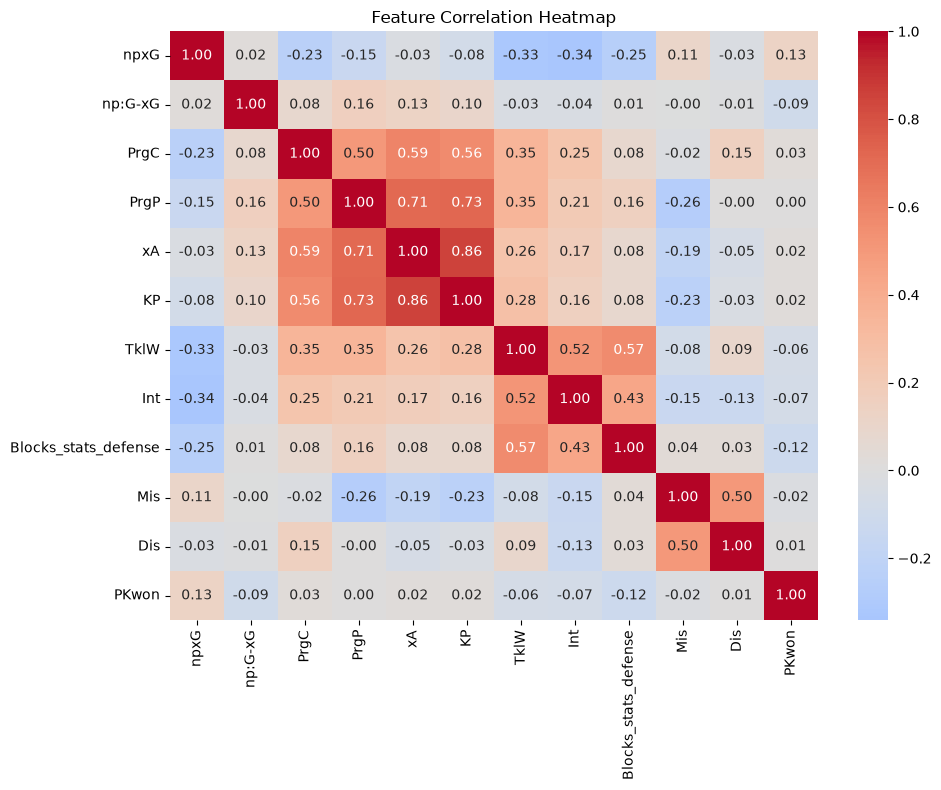

In [176]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,      
    cmap="coolwarm", 
    center=0,        
    fmt=".2f"        
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [177]:
# features_per90['Goal_sco', 'Creativity', 'Defense', 'Ball_control']
# df["xg_score"] = df["xG_per90"].rank(pct=True) * 100
Score_points = pd.DataFrame({
    "Player": features_raw["Player"],
    "Comp": features_raw['Comp']
})
Score_points['Goal_sco'] = 0.5*(features_per90['npxG'].rank(pct=True)*100) + 0.5*(features_per90['np:G-xG'].rank(pct=True)*100)
Score_points['Creativity'] = 0.4*(features_per90['PrgC'].rank(pct=True)*100) + 0.15*(features_per90['PrgP'].rank(pct=True)*100) + 0.25*(features_per90['xA'].rank(pct=True)*100) + 0.2*(features_per90['KP'].rank(pct=True)*100)
Score_points['Defense'] = 0.4*(features_per90['TklW'].rank(pct=True)*100) + 0.4*(features_per90['Int'].rank(pct=True)*100) + 0.2*(features_per90['Blocks_stats_defense'].rank(pct=True)*100)
Score_points['Ball_control'] = 0.5*(features_per90['Mis'].rank(pct=True, ascending=False)*100) + 0.5*(features_per90['Dis'].rank(pct=True, ascending=False)*100)
Score_points['PKwon'] = features_raw['PKwon']
Score_points['Total'] = 0.4*Score_points['Goal_sco'] + 0.3*Score_points['Creativity'] + 0.1*Score_points['Defense'] + 0.185*Score_points['Ball_control'] + 0.25*features_raw['PKwon']

In [178]:
league_weight = {
    "eng Premier League": 1.00,
    "es La Liga": 0.98,
    "it Serie A": 0.96,
    "de Bundesliga": 0.96,
    "fr Ligue 1": 0.96
}

Score_points["League_weight"] = Score_points["Comp"].map(league_weight)
Score_points["Adjusted_Total"] = (
    Score_points["Total"] * Score_points["League_weight"]
)

Score_points = Score_points.sort_values(
    "Adjusted_Total",
    ascending=False
)
print(Score_points)

                Player                Comp  Goal_sco  Creativity  Defense  \
697    Ousmane Dembélé          fr Ligue 1  98.28125   99.000000  36.9375   
1960     Michael Olise       de Bundesliga  76.71875   94.859375  65.3750   
2774      Harry Wilson  eng Premier League  79.21875   52.546875  87.4375   
247      Harvey Barnes  eng Premier League  77.03125   83.453125  38.3750   
238    Bradley Barcola          fr Ligue 1  72.65625   91.609375  80.3125   
...                ...                 ...       ...         ...      ...   
2323  Antonio Sanabria          it Serie A  26.87500    8.468750   9.8125   
2688       Alejo Véliz          es La Liga  18.28125    0.625000  37.6250   
2798   Bertuğ Yıldırım          es La Liga  20.46875   11.804688  34.8750   
126       Marcos André          es La Liga  18.75000   10.054688  48.6250   
1737            Miguel          es La Liga  12.81250    6.828125  34.8125   

      Ball_control  PKwon      Total  League_weight  Adjusted_Total  
697  

In [179]:
Score_points[Score_points['Player'] == 'Erling Haaland']

,Player,Comp,Goal_sco,Creativity,Defense,Ball_control,PKwon,Total,League_weight,Adjusted_Total
1109,Erling Haaland,eng Premier League,71.40625,17.21875,16.1875,91.25,0,52.228125,1.0,52.228125


In [180]:
Score_points[Score_points['Player'] == 'Mohamed Salah']

,Player,Comp,Goal_sco,Creativity,Defense,Ball_control,PKwon,Total,League_weight,Adjusted_Total
2304,Mohamed Salah,eng Premier League,77.65625,87.234375,24.4375,23.4375,0,64.0125,1.0,64.0125


In [181]:
Score_points[Score_points['Player'] == 'Alexander Isak']

,Player,Comp,Goal_sco,Creativity,Defense,Ball_control,PKwon,Total,League_weight,Adjusted_Total
1219,Alexander Isak,eng Premier League,80.9375,59.0625,14.875,45.3125,1,60.214062,1.0,60.214062


In [182]:
Score_points.head(50)

,Player,Comp,Goal_sco,Creativity,Defense,Ball_control,PKwon,Total,League_weight,Adjusted_Total
697,Ousmane Dembélé,fr Ligue 1,98.28125,99.000000,36.9375,50.46875,1,82.292969,0.96,79.001250
1960,Michael Olise,de Bundesliga,76.71875,94.859375,65.3750,66.56250,2,78.496875,0.96,75.357000
2774,Harry Wilson,eng Premier League,79.21875,52.546875,87.4375,96.40625,1,74.280469,1.00,74.280469
247,Harvey Barnes,eng Premier League,77.03125,83.453125,38.3750,78.59375,0,74.225781,1.00,74.225781
238,Bradley Barcola,fr Ligue 1,72.65625,91.609375,80.3125,66.71875,0,76.919531,0.96,73.842750
955,Cody Gakpo,eng Premier League,79.37500,65.781250,77.2500,72.34375,1,72.842969,1.00,72.842969
1011,Serge Gnabry,de Bundesliga,69.53125,79.437500,69.5625,92.03125,0,75.625781,0.96,72.600750
2061,Pedro,it Serie A,81.40625,79.687500,67.3750,60.31250,0,74.364063,0.96,71.389500
2612,Ferrán Torres,es La Liga,94.68750,61.718750,36.9375,68.90625,0,72.832031,0.98,71.375391
2177,Raphinha,es La Liga,61.25000,83.703125,63.0625,88.43750,2,72.778125,0.98,71.322562


In [183]:
Score_points.tail(20)

,Player,Comp,Goal_sco,Creativity,Defense,Ball_control,PKwon,Total,League_weight,Adjusted_Total
2642,Christantus Uche,es La Liga,29.37500,38.859375,61.3125,4.37500,0,30.348437,0.98,29.741469
399,Moritz Broschinski,de Bundesliga,28.28125,39.812500,52.5000,5.62500,0,29.546875,0.96,28.365000
1976,Paul Onuachu,eng Premier League,60.62500,7.765625,14.7500,1.40625,0,28.314844,1.00,28.314844
649,Thijs Dallinga,it Serie A,42.81250,16.531250,27.2500,23.43750,1,29.395313,0.96,28.219500
726,Diego,es La Liga,40.78125,6.062500,10.0625,50.78125,1,28.782031,0.98,28.206391
145,Cameron Archer,eng Premier League,32.34375,14.484375,24.9375,42.34375,0,27.610156,1.00,27.610156
2115,Roberto Piccoli,it Serie A,44.53125,6.718750,12.4375,37.03125,2,28.422656,0.96,27.285750
362,Ange-Yoan Bonny,it Serie A,29.06250,33.968750,33.3125,14.37500,1,28.056250,0.96,26.934000
1196,Rasmus Højlund,eng Premier League,34.21875,17.281250,6.3125,38.43750,1,26.864063,1.00,26.864063
444,Dominic Calvert-Lewin,eng Premier League,40.31250,14.562500,41.4375,11.09375,0,26.689844,1.00,26.689844


# Conclusions

This project develops a multidimensional scoring system for comparing forwards across Europe's top five leagues. Instead of relying on a single statistic such as goals or assists, the model combines goal scoring, creativity, defensive contribution, ball control, and penalties won to provide a broader view of a player's performance.

Using percentile rankings makes it possible to interpret each player's performance relative to other qualified forwards. The final weighted score also reflects the priorities of the model: goal scoring and creativity receive the greatest emphasis, while defense and ball control remain relevant parts of a forward's overall contribution. However, using percentile hides specific data differences. Therefore, following virsion should make an improvement.

I also apply a small league-strength adjustment to account for the different levels of competition across the five leagues. These coefficients are based on my own experience watching European football rather than an objective statistical measurement. For this reason, the adjustment is deliberately limited in size. Its purpose is to slightly distinguish similar performances achieved in different leagues without allowing league strength to outweigh individual performance.

The final rankings should therefore not be interpreted as an objective measurement of player quality. Several decisions in the model—including feature selection, category weights, and league-strength coefficients—reflect my own assumptions about how forwards should be evaluated. The model also does not fully capture factors such as tactical roles, team strength, quality of teammates, or differences in playing style.

Despite these limitations, the model provides a structured way to combine multiple dimensions of forward performance into a single evaluation. More importantly, it creates a framework that can be further tested and improved as additional data or more objective methods for determining weights become available.
